## 07 Xenium Data Audit and SpatialData Conversion

**What this notebook does:** Audits the 10x Xenium pancreatic data from four samples (PDAC, normal), performs QC, and optionally converts to SpatialData zarr format.

**Data files needed:**
- `/Volumes/Shihong_5/for_spatioev/pancreas_Xenium_example_data_from_10X/` (external drive)
- Four sample directories: `pdac_pancreas_v1`, `pdac_io_v1`, `pdac_addon_v1`, `normal_nondiseased_v1`

**How to run:** Connect the external drive and activate `spatioev_env`.

In [1]:
from pathlib import Path
# DATA AVAILABILITY CHECK
import os
# Xenium data requires an external drive mount
_data_root = Path("/Volumes/Shihong_5/for_spatioev/pancreas_Xenium_example_data_from_10X")
_required_files = [_data_root]
_missing = [f for f in _required_files if not os.path.exists(f)]
if _missing:
    print(f'Missing required data files: {_missing}')
    print('   This notebook requires real experimental data to run.')
    print('   The code is shown for reference.')
else:
    print('All required data files found. Notebook is ready to run.')


All required data files found. Notebook is ready to run.


# Xenium Pancreas 10x Data Audit and Optional SpatialData Conversion

This notebook checks the four downloaded 10x Xenium pancreas datasets before we start annotation and pseudotime.

Why this stage matters:

- the public 10x examples use different panels, so we need to know which genes are truly shared
- `spatialdata-io` can manage Xenium outputs nicely
- the downstream notebooks also keep a Scanpy fallback from `cell_feature_matrix.h5` and `cells.csv.gz`, which is faster for tabular annotation/modeling


In [2]:

%matplotlib inline

import os
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")
os.environ.setdefault("NUMBA_CACHE_DIR", "/private/tmp/numba")

from pathlib import Path
import gc
import json
import importlib.util
import tarfile
import warnings
from io import StringIO

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy import sparse

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 8
sns.set_style("white")

ROOT = Path("/Users/shihongwu/SpatioEv")
DATA_ROOT = Path("/Volumes/Shihong_5/for_spatioev/pancreas_Xenium_example_data_from_10X")
OUTPUT_DIR = ROOT / "data" / "xenium_pancreas_10x"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_CONFIGS = [
    {
        "sample_id": "pdac_pancreas_v1",
        "display_name": "Human Pancreas FFPE",
        "disease_group": "PDAC",
        "panel_hint": "Human Multi-Tissue and Cancer",
        "outs_path": DATA_ROOT / "Xenium_V1_human_Pancreas_FFPE_outs",
    },
    {
        "sample_id": "pdac_io_v1",
        "display_name": "Human Ductal Adenocarcinoma FFPE",
        "disease_group": "PDAC",
        "panel_hint": "Human Immuno-Oncology",
        "outs_path": DATA_ROOT / "Xenium_V1_Human_Ductal_Adenocarcinoma_FFPE_outs",
    },
    {
        "sample_id": "pdac_addon_v1",
        "display_name": "hPancreas Cancer Add-on FFPE",
        "disease_group": "PDAC",
        "panel_hint": "Human Multi-Tissue + Add-on",
        "outs_path": DATA_ROOT / "Xenium_V1_hPancreas_Cancer_Add_on_FFPE_outs",
    },
    {
        "sample_id": "normal_nondiseased_v1",
        "display_name": "hPancreas nondiseased section",
        "disease_group": "NormalPancreas",
        "panel_hint": "Human Multi-Tissue and Cancer",
        "outs_path": DATA_ROOT / "Xenium_V1_hPancreas_nondiseased_section_outs",
    },
]

CLINICAL_SAMPLE_METADATA = {
    "normal_nondiseased_v1": {
        "clinical_diagnosis": "Nondiseased pancreas",
        "clinical_stage": "Normal",
        "clinical_grade": "Normal",
        "clinical_grade_order": 0.0,
        "tumor_content_percent": 0.0,
        "clinical_progression_label": "Normal pancreas",
        "clinical_progression_order": 0,
        "clinical_note": "10x nondiseased pancreas reference",
    },
    "pdac_addon_v1": {
        "clinical_diagnosis": "Adenocarcinoma",
        "clinical_stage": "Not provided",
        "clinical_grade": "Grade I-II",
        "clinical_grade_order": 1.5,
        "tumor_content_percent": 50.0,
        "clinical_progression_label": "Grade I-II, 50% tumor",
        "clinical_progression_order": 1,
        "clinical_note": "10x pancreas cancer add-on sample; adenocarcinoma, Grade I-II, 50% tumor",
    },
    "pdac_pancreas_v1": {
        "clinical_diagnosis": "Adenocarcinoma",
        "clinical_stage": "Stage III",
        "clinical_grade": "Not provided",
        "clinical_grade_order": np.nan,
        "tumor_content_percent": np.nan,
        "clinical_progression_label": "Stage III adenocarcinoma",
        "clinical_progression_order": 2,
        "clinical_note": "10x human pancreas FFPE sample; Stage III adenocarcinoma",
    },
    "pdac_io_v1": {
        "clinical_diagnosis": "Pancreatic ductal adenocarcinoma",
        "clinical_stage": "Stage IIB",
        "clinical_grade": "Grade 3",
        "clinical_grade_order": 3.0,
        "tumor_content_percent": np.nan,
        "clinical_progression_label": "Stage IIB, Grade 3 PDAC",
        "clinical_progression_order": 3,
        "clinical_note": "10x human ductal adenocarcinoma FFPE sample; Stage IIB, Grade 3",
    },
}

CLINICAL_SAMPLE_ORDER = [
    "normal_nondiseased_v1",
    "pdac_addon_v1",
    "pdac_pancreas_v1",
    "pdac_io_v1",
]
CLINICAL_LABEL_ORDER = [
    CLINICAL_SAMPLE_METADATA[sample_id]["clinical_progression_label"]
    for sample_id in CLINICAL_SAMPLE_ORDER
]
CLINICAL_PALETTE = {
    "Normal pancreas": "#4daf4a",
    "Grade I-II, 50% tumor": "#ffb000",
    "Stage III adenocarcinoma": "#e41a1c",
    "Stage IIB, Grade 3 PDAC": "#6a3d9a",
}

def clinical_metadata_frame():
    return (
        pd.DataFrame.from_dict(CLINICAL_SAMPLE_METADATA, orient="index")
        .rename_axis("sample_id")
        .reset_index()
        .sort_values("clinical_progression_order")
    )

def attach_clinical_metadata(df):
    meta = clinical_metadata_frame()
    existing_meta_cols = [col for col in meta.columns if col != "sample_id" and col in df.columns]
    if existing_meta_cols:
        df = df.drop(columns=existing_meta_cols)
    return df.merge(meta, on="sample_id", how="left", validate="many_to_one")

def package_available(name):
    return importlib.util.find_spec(name) is not None

def save_df(df, path, index=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.suffix == ".pkl":
        df.to_pickle(path)
    else:
        df.to_csv(path, index=index)

def load_df(path):
    path = Path(path)
    if path.suffix == ".pkl":
        return pd.read_pickle(path)
    return pd.read_csv(path)

def present_columns(df, cols):
    return [c for c in cols if c in df.columns]

def make_sparse_safe_copy(X):
    return X.copy() if sparse.issparse(X) else np.asarray(X).copy()


## Package Status

SpatialData support is available when `spatialdata-io` is installed. The conversion cell below can write `.zarr` stores; if a future environment lacks SpatialData, the notebook records a clear install message and continues with Scanpy-compatible files.


In [3]:

package_status = pd.Series(
    {
        "spatialdata": package_available("spatialdata"),
        "spatialdata_io": package_available("spatialdata_io"),
        "spatialdata_plot": package_available("spatialdata_plot"),
        "pyarrow": package_available("pyarrow"),
        "celltypist": package_available("celltypist"),
        "scvi": package_available("scvi"),
        "scanpy": package_available("scanpy"),
        "anndata": package_available("anndata"),
        "elpigraph": package_available("elpigraph"),
    },
    name="available",
).to_frame()
package_status


,available
spatialdata,True
spatialdata_io,True
spatialdata_plot,True
pyarrow,True
celltypist,False
scvi,False
scanpy,True
anndata,True
elpigraph,True


## Audit Raw Outputs

This reads only lightweight metadata plus the 10x feature matrix headers. It does not load transcript coordinates or full images.


In [4]:

FOCUS_GENES = [
    "EPCAM", "KRT7", "KRT8", "KRT18", "KRT19", "SOX9", "MUC1", "MUC5AC",
    "TFF1", "TFF2", "TFF3", "CEACAM5", "CEACAM6", "AGR2", "AGR3", "S100P",
    "MKI67", "UBE2C", "TOP2A", "CENPF", "CDK1",
    "ACTA2", "PDGFRA", "FAP", "THY1", "PDPN", "DCN", "LUM", "VIM",
    "PECAM1", "VWF", "KDR", "CDH5",
    "PTPRC", "CD3D", "CD3E", "CD4", "CD8A", "FOXP3", "GZMB", "NKG7",
    "CD19", "MS4A1", "CD79A", "MZB1", "JCHAIN", "SDC1",
    "LST1", "LYZ", "CD68", "C1QA", "C1QB", "C1QC",
    "AMY2A", "PRSS1", "PRSS2", "CPA1", "CTRB1", "REG1A",
    "INS", "GCG", "SST", "PPY", "CHGA",
]

audit_rows = []
gene_sets = {}
focus_rows = []

for cfg in SAMPLE_CONFIGS:
    outs = Path(cfg["outs_path"])
    matrix_path = outs / "cell_feature_matrix.h5"
    cells_path = outs / "cells.csv.gz"
    metrics_path = outs / "metrics_summary.csv"
    gene_panel_path = outs / "gene_panel.json"
    cell_groups_path = outs / "cell_groups.csv"

    missing = [
        name
        for name, path in {
            "cell_feature_matrix.h5": matrix_path,
            "cells.csv.gz": cells_path,
            "metrics_summary.csv": metrics_path,
            "gene_panel.json": gene_panel_path,
        }.items()
        if not path.exists()
    ]
    if missing:
        raise FileNotFoundError(f"{cfg['sample_id']} missing required files: {missing}")

    adata_head = sc.read_10x_h5(matrix_path)
    gene_sets[cfg["sample_id"]] = set(adata_head.var_names)
    cells_head = pd.read_csv(cells_path, nrows=5)
    metrics = pd.read_csv(metrics_path)
    metrics_row = metrics.iloc[0].to_dict() if len(metrics) else {}

    audit_rows.append(
        {
            "sample_id": cfg["sample_id"],
            "display_name": cfg["display_name"],
            "disease_group": cfg["disease_group"],
            "panel_hint": cfg["panel_hint"],
            "outs_path": str(outs),
            "n_cells_matrix": int(adata_head.n_obs),
            "n_genes": int(adata_head.n_vars),
            "cells_csv_columns": ", ".join(cells_head.columns),
            "has_cell_groups_csv": cell_groups_path.exists(),
            "panel_name_metrics": metrics_row.get("panel_name", np.nan),
            "num_cells_metrics": metrics_row.get("num_cells_detected", np.nan),
            "median_genes_per_cell": metrics_row.get("median_genes_per_cell", np.nan),
            "median_transcripts_per_cell": metrics_row.get("median_transcripts_per_cell", np.nan),
        }
    )

    for gene in FOCUS_GENES:
        focus_rows.append(
            {
                "sample_id": cfg["sample_id"],
                "disease_group": cfg["disease_group"],
                "gene": gene,
                "present": gene in adata_head.var_names,
            }
        )

audit_df = pd.DataFrame(audit_rows)
focus_gene_df = pd.DataFrame(focus_rows)

common_genes = sorted(set.intersection(*gene_sets.values()))
union_genes = sorted(set.union(*gene_sets.values()))

save_df(audit_df, OUTPUT_DIR / "xenium_dataset_audit.csv")
save_df(focus_gene_df, OUTPUT_DIR / "xenium_focus_gene_availability.csv")
pd.Series(common_genes, name="gene").to_csv(OUTPUT_DIR / "xenium_common_genes.csv", index=False)

print(f"Common genes across all four datasets: {len(common_genes)}")
print(f"Union genes across all four datasets: {len(union_genes)}")
audit_df


Common genes across all four datasets: 98
Union genes across all four datasets: 752


,sample_id,display_name,disease_group,panel_hint,outs_path,n_cells_matrix,n_genes,cells_csv_columns,has_cell_groups_csv,panel_name_metrics,num_cells_metrics,median_genes_per_cell,median_transcripts_per_cell
0,pdac_pancreas_v1,Human Pancreas FFPE,PDAC,Human Multi-Tissue and Cancer,/Volumes/Shihong_5/for_spatioev/pancreas_Xeniu...,140702,377,"cell_id, x_centroid, y_centroid, transcript_co...",False,Xenium Human Multi-Tissue and Cancer Gene Expr...,140702,17,31
1,pdac_io_v1,Human Ductal Adenocarcinoma FFPE,PDAC,Human Immuno-Oncology,/Volumes/Shihong_5/for_spatioev/pancreas_Xeniu...,235099,380,"cell_id, x_centroid, y_centroid, transcript_co...",False,Xenium Human Immuno-Oncology Profiling,235099,27,41
2,pdac_addon_v1,hPancreas Cancer Add-on FFPE,PDAC,Human Multi-Tissue + Add-on,/Volumes/Shihong_5/for_spatioev/pancreas_Xeniu...,190965,474,"cell_id, x_centroid, y_centroid, transcript_co...",True,Xenium Human Multi-Tissue + Add-on Gene Expres...,190965,59,114
3,normal_nondiseased_v1,hPancreas nondiseased section,NormalPancreas,Human Multi-Tissue and Cancer,/Volumes/Shihong_5/for_spatioev/pancreas_Xeniu...,103901,377,"cell_id, x_centroid, y_centroid, transcript_co...",False,Human Multi-Tissue and Cancer Gene Expression,103901,39,109


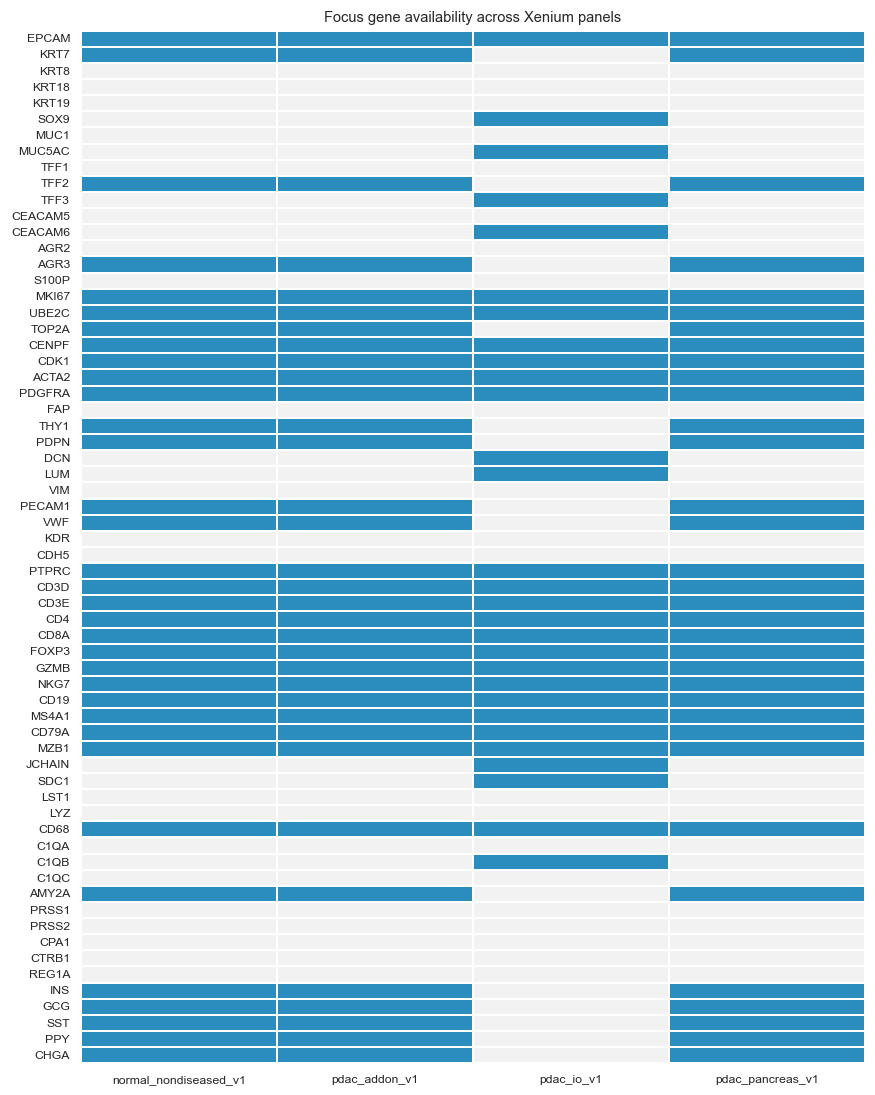

In [5]:

focus_matrix = (
    focus_gene_df
    .pivot_table(index="gene", columns="sample_id", values="present", aggfunc="first")
    .reindex(FOCUS_GENES)
)

plt.figure(figsize=(8, 10))
sns.heatmap(
    focus_matrix.astype(float),
    cmap=sns.color_palette(["#f2f2f2", "#2b8cbe"], as_cmap=True),
    cbar=False,
    linewidths=0.2,
    linecolor="white",
)
plt.title("Focus gene availability across Xenium panels")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


## Optional: Convert Raw Xenium Outputs to SpatialData Zarr

The SpatialData docs describe Xenium loading through `spatialdata_io.xenium(path, ...)`, which reads the Xenium `outs` folder into a `SpatialData` object containing images, labels, points, shapes, and an AnnData table. This conversion is skipped automatically unless `spatialdata_io` is installed.


In [6]:

SPATIALDATA_DIR = OUTPUT_DIR / "spatialdata_zarr"
SPATIALDATA_DIR.mkdir(exist_ok=True)
FORCE_SPATIALDATA_CONVERT = False

if not package_available("spatialdata_io"):
    print(
        "spatialdata_io is not installed in this environment. "
        "If you want SpatialData conversion, install spatialdata, spatialdata-io, spatialdata-plot, and pyarrow in spatioev_env, then rerun this cell."
    )
else:
    from spatialdata_io import xenium

    for cfg in SAMPLE_CONFIGS:
        zarr_path = SPATIALDATA_DIR / f"{cfg['sample_id']}.zarr"
        if zarr_path.exists() and not FORCE_SPATIALDATA_CONVERT:
            print(f"Already exists: {zarr_path}")
            continue

        print(f"Converting {cfg['sample_id']} to SpatialData zarr...")
        sdata = xenium(
            cfg["outs_path"],
            cells_boundaries=False,
            nucleus_boundaries=False,
            cells_as_circles=True,
            transcripts=False,
            cells_labels=False,
            nucleus_labels=False,
            morphology_mip=False,
            morphology_focus=False,
            aligned_images=False,
        )
        sdata.write(zarr_path)
        print(f"Wrote {zarr_path}")


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


Already exists: /Users/shihongwu/SpatioEv/data/xenium_pancreas_10x/spatialdata_zarr/pdac_pancreas_v1.zarr
Already exists: /Users/shihongwu/SpatioEv/data/xenium_pancreas_10x/spatialdata_zarr/pdac_io_v1.zarr
Already exists: /Users/shihongwu/SpatioEv/data/xenium_pancreas_10x/spatialdata_zarr/pdac_addon_v1.zarr
Already exists: /Users/shihongwu/SpatioEv/data/xenium_pancreas_10x/spatialdata_zarr/normal_nondiseased_v1.zarr
